In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline

In [3]:
# Load dataset 
df = pd.read_csv("amz_uk_price_prediction_dataset.csv")

In [4]:
# Display the first few rows of the dataset
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [6]:
# Retrieving the number of rows and columns in the dataframe
df.shape

(2443651, 9)

In [7]:
# Displaying the data types of each column in the dataframe
df.dtypes

uid                    int64
asin                  object
title                 object
stars                float64
reviews                int64
price                float64
isBestSeller            bool
boughtInLastMonth      int64
category              object
dtype: object

In [8]:
# Extracting column names with numerical data types from the dataframe
df.select_dtypes("number").columns

Index(['uid', 'stars', 'reviews', 'price', 'boughtInLastMonth'], dtype='object')

In [9]:
# Counting and sorting the unique values for each numerical column in descending order
df.select_dtypes("number").nunique().sort_values(ascending=False)

uid                  2443651
price                  82916
reviews                19446
stars                     42
boughtInLastMonth         25
dtype: int64

## Data cleaning

In [10]:
# Clean Column Names
# Removes hidden characters or backslashes often found in scraped headers
df.columns = df.columns.str.strip().str.replace('\\', '', regex=False)

In [11]:
# Remove Missing Values
# We drop rows where critical analysis columns (price, stars, category) are empty.
df = df.dropna(subset=['price', 'stars', 'category'])

In [12]:
# Standardize Data Types
# Ensure numeric columns are floats/ints. 'coerce' turns any unexpected text into NaN.
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['stars'] = pd.to_numeric(df['stars'], errors='coerce')
df['reviews'] = pd.to_numeric(df['reviews'], errors='coerce')

In [14]:
#  Remove Missing Values
# We drop rows where price or stars are missing because they are useless for prediction/analysis
df = df.dropna(subset=['price', 'stars', 'category'])

In [15]:
# Handle Duplicates
# Remove duplicate listings based on the unique Product ID (asin).
df = df.drop_duplicates(subset=['asin'])

In [16]:
# Ensure ratings are on the 1-5 scale and prices are not negative.
df = df[(df['stars'] >= 1) & (df['stars'] <= 5)]
df = df[df['price'] >= 0]

In [17]:
df.shape

(1048322, 9)

# Part 1: Understanding Product Categories

**Business Question:**
* What are the most popular product categories on Amazon UK?
* How do they compare in terms of listing frequency?

## Frequency Tables
* Generate a frequency table for the product category.
* Which are the top 5 most listed product categories?

## Visualizations
* **Bar Chart:** Display the distribution of products across different categories. (If the chart is too crowded, do it for a subset of the top categories).
* **Pie Chart:** For a subset of top categories, visualize their proportions using a pie chart . 

* Does any category dominate the listings?*

In [18]:
# Frequency Tables
#  Generate a frequency table for product categories
# .value_counts() counts how many times each unique category appears
category_freq = df['category'].value_counts()

In [19]:
# Display the top 5 most listed product categories
print("Top 5 Most Listed Categories:")
print(category_freq.head(5))

Top 5 Most Listed Categories:
category
Sports & Outdoors    141543
Skin Care             17945
Make-up               16866
Men                   16080
Women                 16016
Name: count, dtype: int64


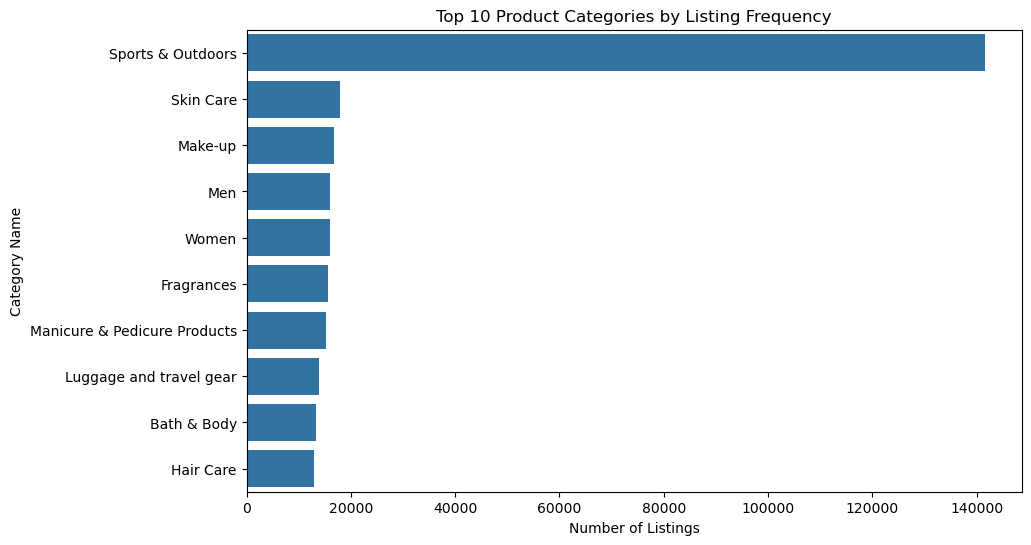

In [20]:
#  Visualization: Bar Chart

plt.figure(figsize=(10, 6))
# We plot the top 10 to keep the chart readable
sns.barplot(x=category_freq.head(10).values, y=category_freq.head(10).index)
plt.title('Top 10 Product Categories by Listing Frequency')
plt.xlabel('Number of Listings')
plt.ylabel('Category Name')
plt.show()

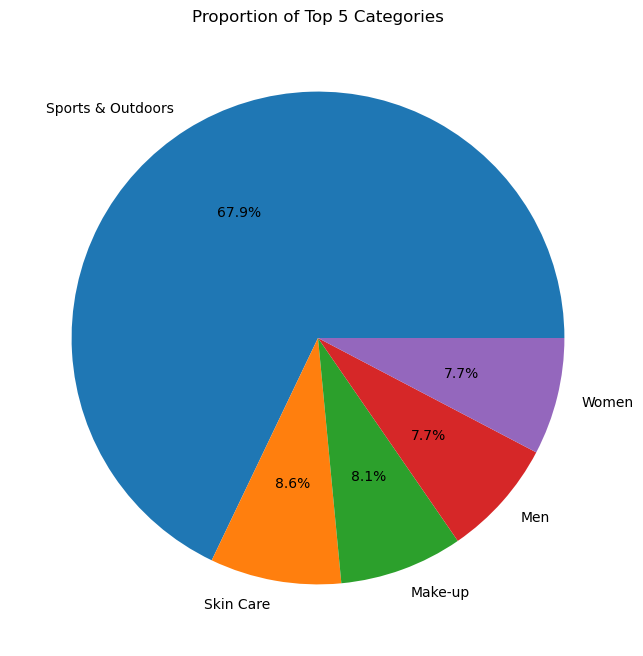

In [21]:
#  Visualization: Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(category_freq.head(5), labels=category_freq.head(5).index, autopct='%1.1f%%')
plt.title('Proportion of Top 5 Categories')
plt.show()

<Axes: title={'center': 'Proportion of Top 5 Categories'}, ylabel='count'>

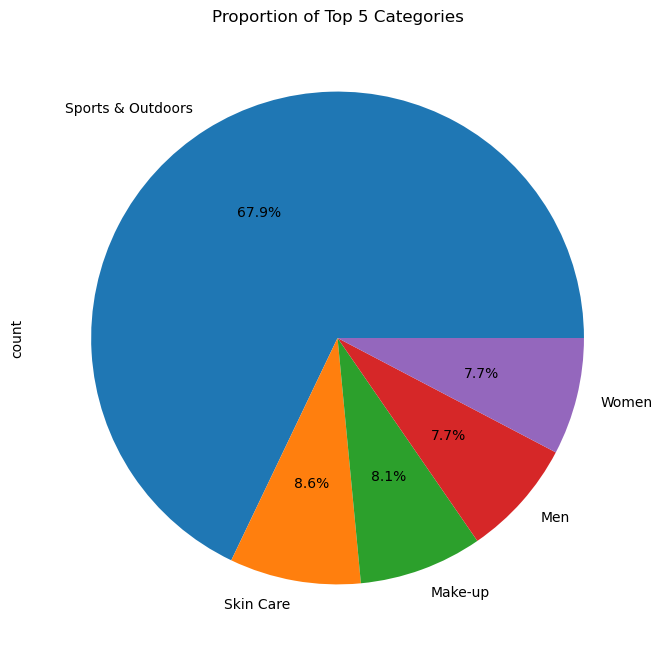

In [24]:
# Plotting a pie chart of the top 5 category frequencies, with percentage labels,
# and setting the figure size to 8x8 using matplotlib's figure parameter
category_freq.head(5).plot.pie(autopct='%1.1f%%', figsize=(8, 8), title='Proportion of Top 5 Categories')

Text(0.5, 1.0, 'Top 5 Product Categories')

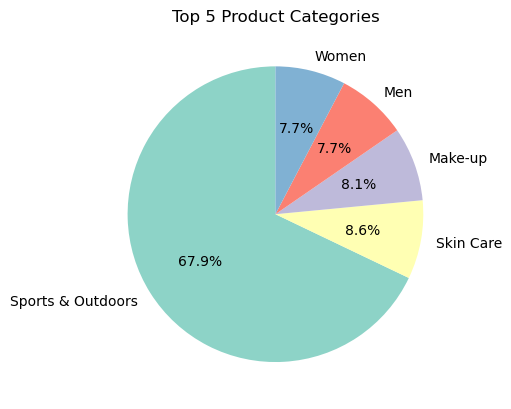

In [26]:
df['category'].value_counts().head(5).plot.pie(
    autopct='%1.1f%%', 
    startangle=90, 
    colors=sns.color_palette("Set3")
)
plt.ylabel('') # This hides the word "category" from the side of the chart
plt.title("Top 5 Product Categories")

## The top 5 categories are Women, Men, Make-up, skincare and Sports & Outdoors. Sports  & Outdoors dominate the listings

# Part 2: Delving into Product Pricing

**Business Question:** How are products priced on Amazon UK, and are there specific price points or ranges that are more common?

### Measures of Centrality:
* Calculate the mean, median, and mode for the price of products.
* What's the average price point of products listed? How does this compare with the most common price point (mode)?

### Measures of Dispersion:
* Determine the variance, standard deviation, range, and interquartile range for product price.
* How varied are the product prices? Are there any indicators of a significant spread in prices?

### Visualizations:
* Is there a specific price range where most products fall? Plot a histogram to visualize the distribution of product prices. If its hard to read these diagrams, think why this is, and explain how it could be solved..
* Are there products that are priced significantly higher than the rest? Use a box plot to showcase the spread and potential outliers in product pricing.

In [30]:
# Measures of Centrality:

mean_price = df['price'].mean()
median_price = df['price'].median()
mode_price = df['price'].mode()[0]

mean_price, median_price, mode_price


(np.float64(46.74169819959898), 16.99, np.float64(9.99))

In [31]:
# Measures of Centrality:
mean_p = df['price'].mean()
median_p = df['price'].median()
mode_p = df['price'].mode()[0]

print(f"Mean: {mean_p:.2f}, Median: {median_p:.2f}, Mode: {mode_p:.2f}")

Mean: 46.74, Median: 16.99, Mode: 9.99


#The average price point is £46.74, which is significantly higher than the most common price point of £9.99. This indicates that while most items are priced affordably, the presence of high-priced outliers is skewing the average upward, creating a right-skewed distribution.

#The Interpretation: This massive difference tells us that the "typical" price a customer sees most often is very low (under £10). However, the average is being "pulled" much higher by a small number of very expensive, high-end products

In [35]:
# Measures of Dispersion:
var_p = df['price'].var()
std_p = df['price'].std()
range_p = df['price'].max() - df['price'].min()
iqr_p = df['price'].quantile(0.75) - df['price'].quantile(0.25)

print(f"Var: {var_p:.2f}, Std: {std_p:.2f}, Range: {range_p:.2f}, IQR: {iqr_p:.2f}")

Var: 17774.54, Std: 133.32, Range: 19990.00, IQR: 25.84


#The product prices exhibit extreme variation. While the IQR ($25.84$) suggests that the middle $50\%$ of the market is concentrated in a narrow price band, the Standard Deviation ($133.32$) and Range ($19,990.00$) indicate a massive overall spread. This signifies that the category is dominated by low-cost items but is heavily skewed by extreme high-value outliers.

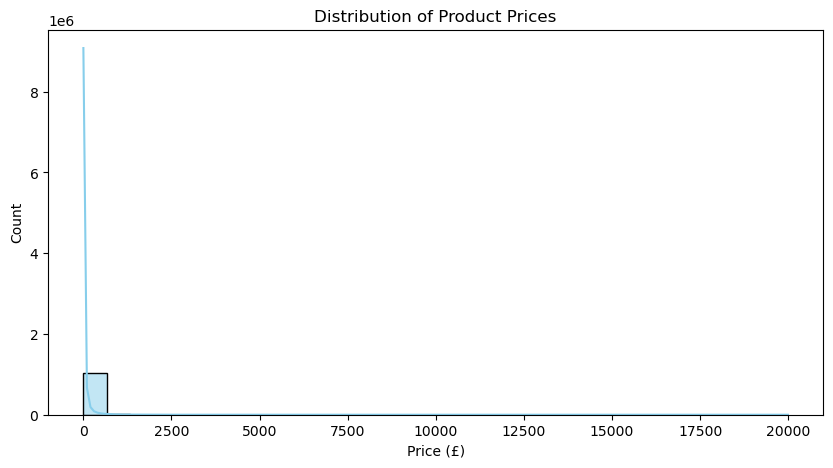

In [36]:
# Visualizations: 
# Histogram
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Product Prices')
plt.xlabel('Price (£)')
plt.show()

#When we plot the raw data, we likely see one , thin bar at the far left and a long, flat empty space stretching to the right. This happens because:

Extreme Outliers: Your Range is £19,990.00. To fit a £20,000 value on the same horizontal line as a £9.99 value, the computer has to "squish" the scale.

Skewness: Because 99% of your products are cheap and 0.1% are incredibly expensive, the "common" products get crowded into a single pixel-width column, while the x-axis is wasted on the empty space between the average products and the luxury outliers.

#How to solve this?
To make the diagram useful for business analysis, you can use these two professional solutions:

Solution A: Filtering (The "Zoom" Method): Limit the x-axis to a reasonable threshold. For example, plotting only products under £200. This removes the outliers and allows you to actually see the "hump" of the distribution where most customers shop.


<Axes: xlabel='price', ylabel='Count'>

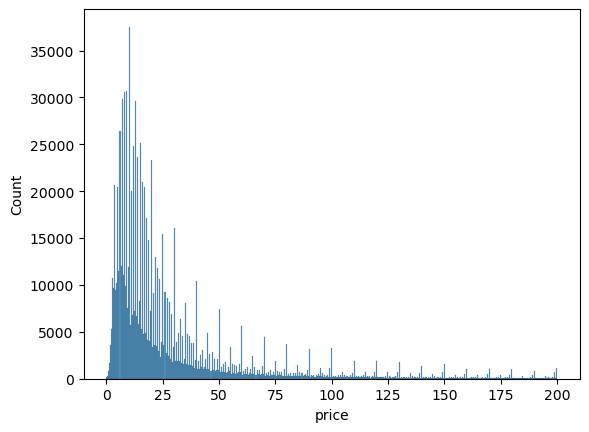

In [39]:
sns.histplot(df[df['price'] < 200]['price'])

# Part 3: Unpacking Product Ratings
Business Question: How do customers rate products on Amazon UK, and are there any patterns or tendencies in the ratings?

Measures of Centrality:

Calculate the mean, median, and mode for the rating of products.
How do customers generally rate products? Is there a common trend?
Measures of Dispersion:

Determine the variance, standard deviation, and interquartile range for product rating.
Are the ratings consistent, or is there a wide variation in customer feedback?
Shape of the Distribution:

Calculate the skewness and kurtosis for the rating column.
Are the ratings normally distributed, or do they lean towards higher or lower values?
Visualizations:

Plot a histogram to visualize the distribution of product ratings. Is there a specific rating that is more common?


# Part 3: Unpacking Product Ratings

**Business Question:** How do customers rate products on Amazon UK, and are there any patterns or tendencies in the ratings?

### Measures of Centrality:
* Calculate the mean ($\bar{x}$), median ($M$), and mode ($Mo$) for the rating of products.
* How do customers generally rate products? Is there a common trend ?

### Measures of Dispersion:
* Determine the variance ($\sigma^2$), standard deviation ($\sigma$), and interquartile range ($IQR$) for product rating.
* Are the ratings consistent , or is there a wide variation in customer feedback?

### Shape of the Distribution:
* Calculate the **Skewness** and **Kurtosis** for the rating column.
* Are the ratings normally distributed, or do they lean towards higher or lower values ?

### Visualizations:
* Plot a histogram to visualize the distribution of product ratings. 
* Is there a specific rating that is more common? 

In [46]:
# Measures of Centrality
mean_r = df['stars'].mean()
median_r = df['stars'].median()
mode_r = df['stars'].mode()[0]
print(f"Mean: {mean_r:.2f}, Median: {median_r:.2f}, Mode: {mode_r:.2f}")

Mean: 4.31, Median: 4.40, Mode: 4.50


Customers generally rate products very positively, with the most common rating (Mode) being 4.50. The trend shows a negative skew, where the mean is lower than the median and mode. This indicates that while the vast majority of feedback is excellent, a small percentage of low ratings is pulling the overall average down.

In [47]:
# Measures of Dispersion:
std_r = df['stars'].std()
std_r = df['stars'].std()
iqr_r = df['stars'].quantile(0.75) - df['stars'].quantile(0.25)
print(f"Std Dev: {std_r:.2f}, IQR: {iqr_r:.2f}")

Std Dev: 0.57, IQR: 0.50


The customer feedback is remarkably consistent. With a Standard Deviation of 0.57 and an IQR of 0.50, there is no evidence of a wide variation or 'polarization' in ratings. Instead, the data shows a high level of consensus among consumers, with the vast majority of products receiving consistently high scores.

In [48]:
# Shape of the Distribution:¶
skew_r = df['stars'].skew()
kurt_r = df['stars'].kurtosis()

print(f"Skewness: {skew_r:.2f}, Kurtosis: {kurt_r:.2f}")

Skewness: -2.36, Kurtosis: 9.45


Skewness: -2.36 
Because the skewness is negative, the ratings lean heavily towards higher values.

In a normal distribution, this number would be 0.

A value of -2.36 means the "tail" of graph is pulled far to the left (towards 1 and 2 stars), while the big "hump" of data is sitting on the right (at 4 and 5 stars).

Simple meaning: Most customers are very happy, and only a tiny minority are leaving low scores.

Kurtosis: 9.45 
Kurtosis measures how "peaky" or "flat" data is.

A normal distribution has a kurtosis of 3.

The value of 9.45 is much higher, which makes it Leptokurtic.

Simple meaning: This indicates a "extreme peak." Instead of ratings being spread out across the 1–5 scale, they are intensely clustered together. Almost every product is getting almost the exact same high score.

The ratings are not normally distributed. The Skewness of -2.36 indicates a significant lean towards higher values, showing that customers predominantly give high ratings. The Kurtosis of 9.45 shows that the distribution is Leptokurtic, meaning the ratings are not spread out but are highly concentrated around a specific high score. This confirms that there is a strong consensus of satisfaction among Amazon UK customers

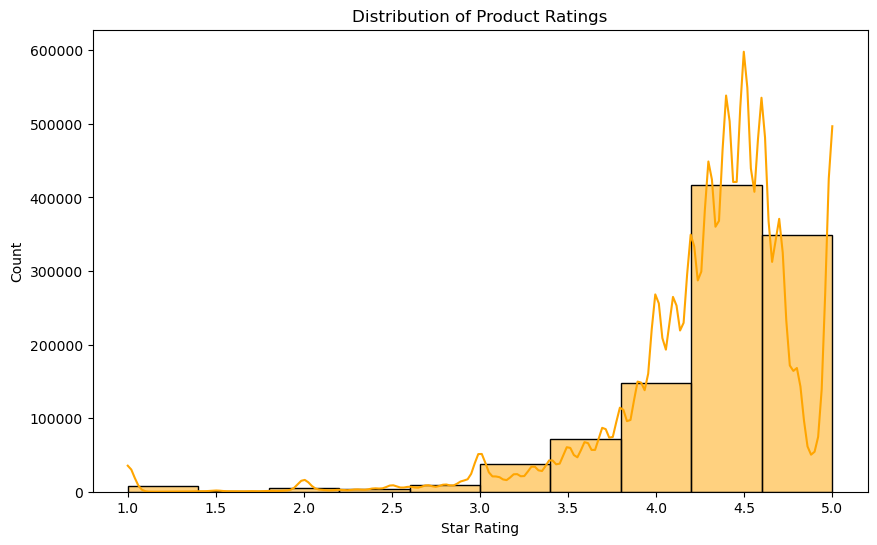

In [49]:
# Visualizations: Histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['stars'], bins=10, kde=True, color='orange')
plt.title('Distribution of Product Ratings')
plt.xlabel('Star Rating')
plt.show()

The Most Common Rating: 4.50